In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

# School Rankings

In [2]:
import requests
from bs4 import BeautifulSoup
import html5lib
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import urllib.request

In [3]:
Initial_data_path = 'NSW_Schools.csv'
school_ranking_data = pd.read_csv(Initial_data_path)
school_codes = school_ranking_data['ACARA ID']
school_ranking_data.head()
school_names_alt = list(school_ranking_data['School Name'])

In [4]:
basic_URL = "https://bettereducation.com.au/Results/Hsc.aspx"
try:
    webpage_source = requests.get(basic_URL).text
except:
    print('Error Occured')
try:
    content = BeautifulSoup(webpage_source, 'html5lib')
    content
except:
        print('Error Occured')

In [5]:
def id_constructor(start='ctl00_ContentPlaceHolder1_GridView1_ctl',end='_HyperLinkSchool',number='0'):
    new_id = str(start) + str(number) + str(end)
    return new_id
id_constructor(number='06')

'ctl00_ContentPlaceHolder1_GridView1_ctl06_HyperLinkSchool'

In [6]:
id_con = str(id_constructor(number=102))
id_real = 'ctl00_ContentPlaceHolder1_GridView1_ctl02_HyperLinkSchool'
print(id_real)
print(id_con)
print(id_real == id_con)

ctl00_ContentPlaceHolder1_GridView1_ctl02_HyperLinkSchool
ctl00_ContentPlaceHolder1_GridView1_ctl102_HyperLinkSchool
False


In [7]:
ids = []
for i in range(300):
    ids.append(str(str(i).zfill(2)))

id_codes = []
for i in ids:
    id_codes.append(id_constructor(number=i))

In [9]:
content.find('a', id='code').text

AttributeError: 'NoneType' object has no attribute 'text'

In [13]:
content

<!DOCTYPE html>
<html><head id="ctl00_Head1"><link href="/images/bettereducation.ico" rel="SHORTCUT ICON"/><meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/><meta content="goZn-QcZz7zjODwX79TSAa8qFN2VxNIXEnSWz7trl6E" name="google-site-verification"/><title>
	Top Schools by HSC Results - 2023
</title><meta content="67EC1937AA9602E3E4990DD6BF5A3AD9" name="msvalidate.01"/><meta content="info+at+bettereducation.com.au" name="Owner"/><meta content="Better Education Pty Ltd" name="author"/><meta content="Global" name="distribution"/><meta content="Safe For Kids" name="rating"/><meta content="Better Education Pty Ltd, All rights reserved 2008-2024" name="copyright"/><meta content="2023, nsw, sydney, school ranking, hsc, da, atar, results, score, best, top, high school, college, secondary school, suburb, 10, 50, 100, 200, " id="ctl00_PageKeywords" name="Keywords"/><meta content="HSC school ranking - HSC results | Better Education - 2023" id="ctl00_PageDescription" name="Descriptio

Begin extracting all important information

In [12]:
school_names = []
for code in id_codes:
    try:
        #print(id_constructor(number=nums))
        name = content.find('a', id=code).text
        school_names.append(name)
    except:
        continue


Each schools 'Percentage of exams sat that achieved DA':

In [18]:
percentDA_codes = []
for i in ids:
    percentDA_codes.append(id_constructor(start='ctl00_ContentPlaceHolder1_GridView1_ctl', end='_lblPercent', number=i))

In [36]:
school_percentageDA = []
for code in percentDA_codes:
    try:
        percent_DA = content.find('span', id=code).text
        school_percentageDA.append(percent_DA)
    except:
        continue

Constructing the Dataframe

In [37]:
school_ranking_data = {
    'school_name': school_names,
    'school_achievement': school_percentageDA
}
school_ranking_data = pd.DataFrame(school_ranking_data)
school_ranking_data

,school_name,school_achievement
0,North Sydney Boys High School,69.0%
1,James Ruse Agricultural High School,60.0%
2,Baulkham Hills High School,55.8%
3,North Sydney Girls High School,54.7%
4,Reddam House,54.2%
...,...,...
200,Broughton Anglican College (Menangle Park),5.8%
201,St Columba's Catholic College (Springwood),5.8%
202,Cedars Christian College,5.7%
203,"St Philip's Christian College,Salamander Bay,N...",5.6%


Attempting to combine the dataset of Lat-Longitude with Ranking results

In [38]:
school_names_rank = set(school_names)
school_names_full = set(school_names_alt)


In [39]:
len(school_names_rank), len(school_names_full)

(205, 3216)

In [50]:
school_names_200_new = []
for school in school_names_rank:
    new_name = school.split(',')[0]
    new_name = new_name.split('(')[0]
    school_names_200_new.append(new_name)

valid_schools = list(set(school_names_200_new) & set(school_names_full))

In [51]:
len(valid_schools)

161

In [56]:
Initial_data_path = 'NSW_Schools.csv'
school_data = pd.read_csv(Initial_data_path)
school_codes = school_data['ACARA ID']
latitudes = school_data['Latitude']
longitudes = school_data['Longitude']
gdf = gpd.GeoDataFrame(school_data, geometry=gpd.points_from_xy(longitudes, latitudes))

0       A.G.B.U. Alexander Primary School
1                Abbotsford Public School
2                             Abbotsleigh
3               Abbotsleigh Junior School
4                  Aberdeen Public School
                      ...                
3416                  Young Public School
3417              Yowie Bay Public School
3418                    Yudi Gunyi School
3419                 Zahra Grammar School
3420                Zig Zag Public School
Name: School Name, Length: 3421, dtype: object

In [67]:
school_locations={
    'name': gdf['School Name'],
    'coordinates': gdf['geometry']
}
school_locations=gpd.GeoDataFrame(school_locations)
school_locations.set_index('name',inplace=True)
school_locations.set_geometry('coordinates',inplace=True)
school_locations.head()

,coordinates
name,
A.G.B.U. Alexander Primary School,POINT (151.18715 -33.67679)
Abbotsford Public School,POINT (151.13100 -33.85270)
Abbotsleigh,POINT (151.11100 -33.71990)
Abbotsleigh Junior School,POINT (151.11300 -33.71620)
Aberdeen Public School,POINT (150.88800 -32.16610)


In [71]:
complete_data = school_locations.merge(
    right = school_ranking_data, 
    how = 'inner',
    left_index = True,
    right_on = 'school_name')

In [74]:
complete_data.head()

,coordinates,school_name,school_achievement
170,POINT (150.98400 -33.80470),Catherine McAuley Westmead,9.5%
79,POINT (151.10000 -33.76950),Epping Boys High School,18.8%
29,POINT (151.01700 -33.78890),Tara Anglican School for Girls,34.1%
123,POINT (150.99600 -33.81790),Parramatta High School,13.4%
24,POINT (151.27200 -33.86560),Kambala,35.7%


AttributeError: PathCollection.set() got an unexpected keyword argument 'colour'

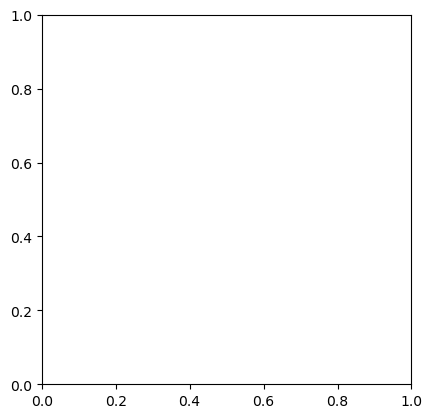

In [75]:
complete_data.plot(colour='school_achievement')